# Latent Observation Methods Summary (setting4)

Companion to `analyze_observations.ipynb`, but for the latent-observation transfer methods run by `run_observation_exp.sh` (`obs_models=(vae lusr curl atc)`) on `tempe_1x1` / `setting4`.

All four runs share the same logged `exp_name` (`tempe_1x1_setting4_presslight_latent_observation`), so they are distinguished by run order in `run_observation_exp.sh`. The `lusr` run is the only one that prints a load line (`Loading cached latent encoders from pretrained/lusr/tempe_1x1`) and it lands at run-order position 2 exactly as expected, which anchors the mapping below.

Metric rule for the latent methods (mirrors `domain_randomization` in the sibling notebook): for each method take the top `TOP_REWARD_K` real-rollout rows by `reward` (from `TEST_REAL`/`TRAIN_REAL`) in its `_DTL.log`, then average their metrics.

`direct_transfer` is included for reference, read exactly as in `analyze_observations.ipynb`: the `TEST_REAL` episode-1 row from the newest `domain_randomization/setting4` log (a single row, so no std). Gaps are reported as ATT minus the cityflow direct-transfer baseline.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

LOG_DIR = Path('data/output_data/sim2real_observations/cityflow_presslight/tempe_1x1/test/logger')
CITYFLOW_DT_DIR = Path('logs/sim2real_observations/presslight/tempe_1x1/cityflow_direct_transfer')
DIRECT_TRANSFER_DIR = Path('logs/sim2real_observations/presslight/tempe_1x1/domain_randomization/setting4')
DIRECT_TRANSFER_EPISODE = 1

NETWORK = 'tempe_1x1'
SETTING = 'setting4'
TOP_REWARD_K = 5

# Run order from run_observation_exp.sh: obs_models=(vae lusr curl atc).
# lusr confirmed via its 'pretrained/lusr' load line at position 2.
LATENT_METHODS = ['vae', 'lusr', 'curl', 'atc']
LOG_FILES = {
    'vae':  '2026_06_01-09_46_26_DTL.log',
    'lusr': '2026_06_01-10_12_10_DTL.log',
    'curl': '2026_06_01-10_32_06_DTL.log',
    'atc':  '2026_06_01-11_01_12_DTL.log',
}
# Order used in tables and plots (direct_transfer reference first).
METHOD_ORDER = ['direct_transfer', *LATENT_METHODS]

COLUMNS = ['exp_name', 'mode', 'episode', 'travel_time', 'aux', 'reward', 'queue', 'delay', 'throughput']
METRIC_COLUMNS = ['travel_time', 'aux', 'reward', 'queue', 'delay', 'throughput']
NUMERIC_COLUMNS = ['episode', *METRIC_COLUMNS]
REAL_MODES = ['TEST_REAL', 'TRAIN_REAL']


def read_tabular_dtl(log_path: Path):
    df = pd.read_csv(log_path, sep='\t', header=None, names=COLUMNS)
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def newest_dtl(log_dir: Path):
    logs = sorted(log_dir.glob('*_DTL.log')) if log_dir.exists() else []
    return logs[-1] if logs else None


def read_cityflow_baseline_att():
    log_path = newest_dtl(CITYFLOW_DT_DIR)
    if log_path is None:
        return pd.NA
    df = read_tabular_dtl(log_path)
    final = df[df['mode'] == 'FINAL_TEST']
    if final.empty:
        return pd.NA
    return float(final.iloc[-1]['travel_time'])


CITYFLOW_ATT = read_cityflow_baseline_att()
CITYFLOW_ATT

143.0

## Picked Metric Mean and Std

Latent methods: top `TOP_REWARD_K` real-rollout rows by reward, averaged. `direct_transfer`: single `TEST_REAL` episode-1 row (no std). Cells are `mean ± std`.

In [2]:
def selected_latent_rows(log_path: Path, top_k: int = TOP_REWARD_K):
    df = read_tabular_dtl(log_path)
    real = df[df['mode'].isin(REAL_MODES)].copy()
    real = real[real['travel_time'].notna() & real['reward'].notna()]
    return real.sort_values('reward', ascending=False).head(top_k).copy()


def selected_direct_transfer_rows():
    log_path = newest_dtl(DIRECT_TRANSFER_DIR)
    if log_path is None:
        return pd.DataFrame(columns=COLUMNS), None
    df = read_tabular_dtl(log_path)
    real = df[(df['mode'] == 'TEST_REAL') & df['travel_time'].notna()].copy()
    if real.empty:
        return real, log_path
    target = real[real['episode'] == DIRECT_TRANSFER_EPISODE]
    chosen = target.head(1) if not target.empty else real.sort_values('episode').head(1)
    return chosen.copy(), log_path


def selected_rows_for_method(method: str):
    if method == 'direct_transfer':
        return selected_direct_transfer_rows()
    log_path = LOG_DIR / LOG_FILES[method]
    return selected_latent_rows(log_path), log_path


def format_mean_std(mean_value, std_value):
    if pd.isna(mean_value):
        return pd.NA
    if pd.isna(std_value):
        return f'{mean_value:.1f}'
    return f'{mean_value:.1f} ± {std_value:.1f}'


summary_rows = []
for method in METHOD_ORDER:
    selected, log_path = selected_rows_for_method(method)
    row = {
        'network': NETWORK,
        'setting': SETTING,
        'method': method,
        'selection_count': int(len(selected)),
        'selected_episodes': ', '.join(str(int(e)) for e in selected['episode'].dropna()),
        'log_file': log_path.name if log_path is not None else pd.NA,
    }
    for metric in METRIC_COLUMNS:
        values = selected[metric].dropna()
        row[f'{metric}_mean'] = float(values.mean()) if not values.empty else pd.NA
        row[f'{metric}_std'] = float(values.std(ddof=1)) if len(values) > 1 else pd.NA
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

display_df = summary_df[['network', 'setting', 'method']].copy()
for metric in METRIC_COLUMNS:
    display_df[metric] = [
        format_mean_std(m, s)
        for m, s in zip(summary_df[f'{metric}_mean'], summary_df[f'{metric}_std'])
    ]
display_df['selected_episodes'] = summary_df['selected_episodes']
display_df = display_df[['network', 'setting', 'method', *METRIC_COLUMNS, 'selected_episodes']]
display_df.to_csv('latent_observation_table.csv', index=False)
display_df

,network,setting,method,travel_time,aux,reward,queue,delay,throughput,selected_episodes
0,tempe_1x1,setting4,direct_transfer,639.0,100.0,-293.1,227.8,1.7,1311.0,1
1,tempe_1x1,setting4,vae,160.4 ± 5.1,100.0 ± 0.0,-20.0 ± 2.8,35.0 ± 5.5,1.7 ± 0.1,1863.0 ± 8.2,"134, 102, 76, 65, 133"
2,tempe_1x1,setting4,lusr,201.4 ± 8.9,100.0 ± 0.0,-43.4 ± 5.2,52.8 ± 9.8,1.6 ± 0.2,1817.4 ± 17.6,"82, 172, 80, 74, 72"
3,tempe_1x1,setting4,curl,244.8 ± 24.5,100.0 ± 0.0,-68.8 ± 13.9,69.6 ± 14.0,1.9 ± 0.3,1760.0 ± 30.9,"197, 196, 191, 169, 198"
4,tempe_1x1,setting4,atc,299.1 ± 10.0,100.0 ± 0.0,-100.4 ± 5.8,89.6 ± 18.0,1.7 ± 0.3,1694.8 ± 13.3,"106, 158, 190, 193, 125"


## Gap vs Cityflow Direct Transfer

In [3]:
gap_df = summary_df[['network', 'setting', 'method']].copy()
gap_df['travel_time'] = summary_df['travel_time_mean']
gap_df['travel_time_std'] = summary_df['travel_time_std']
gap_df['reward'] = summary_df['reward_mean']
gap_df['queue'] = summary_df['queue_mean']
gap_df['delay'] = summary_df['delay_mean']
gap_df['throughput'] = summary_df['throughput_mean']
gap_df['cityflow_direct_transfer'] = CITYFLOW_ATT
gap_df['gap_vs_cityflow'] = gap_df['travel_time'] - CITYFLOW_ATT
gap_df['log_file'] = summary_df['log_file']
gap_df = gap_df.round(1)
gap_df

,network,setting,method,travel_time,travel_time_std,reward,queue,delay,throughput,cityflow_direct_transfer,gap_vs_cityflow,log_file
0,tempe_1x1,setting4,direct_transfer,639.0,<NA>,-293.1,227.8,1.7,1311.0,143.0,496.0,2026_05_18-03_06_13_DTL.log
1,tempe_1x1,setting4,vae,160.4,5.068728,-20.0,35.0,1.7,1863.0,143.0,17.4,2026_06_01-09_46_26_DTL.log
2,tempe_1x1,setting4,lusr,201.4,8.903202,-43.4,52.8,1.6,1817.4,143.0,58.4,2026_06_01-10_12_10_DTL.log
3,tempe_1x1,setting4,curl,244.8,24.537971,-68.8,69.6,1.9,1760.0,143.0,101.8,2026_06_01-10_32_06_DTL.log
4,tempe_1x1,setting4,atc,299.1,10.034939,-100.4,89.6,1.7,1694.8,143.0,156.1,2026_06_01-11_01_12_DTL.log


## Gap Bar Chart

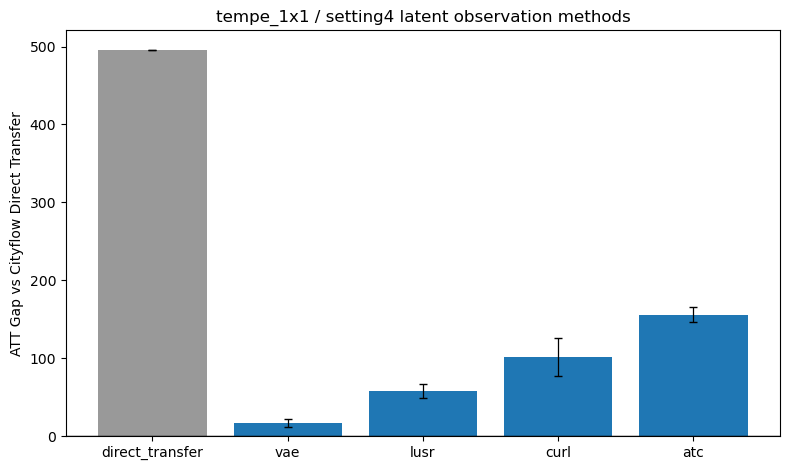

In [4]:
import matplotlib.pyplot as plt

plot_df = gap_df.set_index('method').reindex(METHOD_ORDER)
x = np.arange(len(METHOD_ORDER))
values = pd.to_numeric(plot_df['gap_vs_cityflow'], errors='coerce').to_numpy(dtype=float)
errors = pd.to_numeric(plot_df['travel_time_std'], errors='coerce').to_numpy(dtype=float)
errors = np.where(np.isnan(errors), 0, errors)
colors = ['0.6' if m == 'direct_transfer' else 'C0' for m in METHOD_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x, values, yerr=errors, capsize=3, ecolor='black', error_kw={'linewidth': 0.9}, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel('ATT Gap vs Cityflow Direct Transfer')
ax.set_title(f'{NETWORK} / {SETTING} latent observation methods')
fig.tight_layout()
plt.show()

## Real-Test Travel-Time Traces

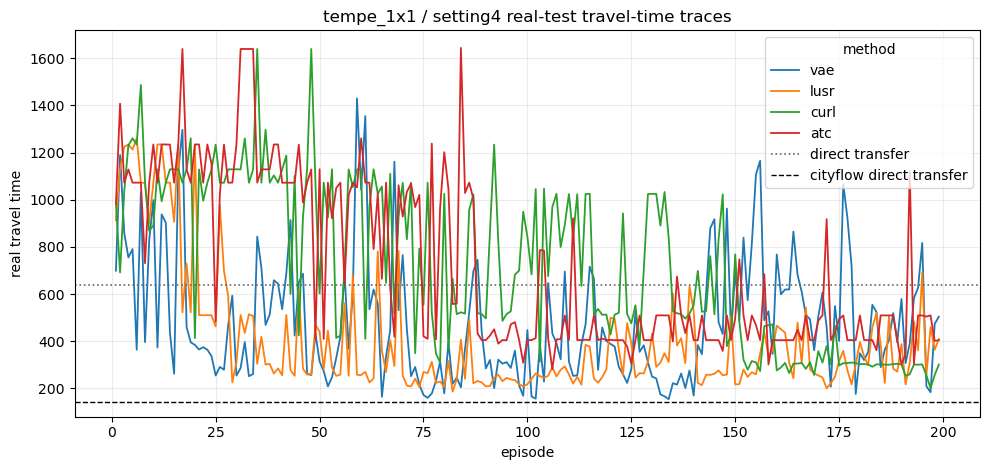

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for method in LATENT_METHODS:
    df = read_tabular_dtl(LOG_DIR / LOG_FILES[method])
    trace = df[df['mode'].isin(REAL_MODES)].sort_values('episode')
    if trace.empty:
        continue
    ax.plot(trace['episode'], trace['travel_time'], linewidth=1.3, label=method)

direct_att = pd.NA
if 'direct_transfer' in gap_df['method'].values:
    direct_att = gap_df.set_index('method').loc['direct_transfer', 'travel_time']
if pd.notna(direct_att):
    ax.axhline(direct_att, color='0.4', linestyle=':', linewidth=1.2, label='direct transfer')
if pd.notna(CITYFLOW_ATT):
    ax.axhline(CITYFLOW_ATT, color='black', linestyle='--', linewidth=1, label='cityflow direct transfer')
ax.set_xlabel('episode')
ax.set_ylabel('real travel time')
ax.set_title(f'{NETWORK} / {SETTING} real-test travel-time traces')
ax.grid(True, alpha=0.25)
ax.legend(title='method')
fig.tight_layout()
plt.show()